# 1) Đọc dữ liệu


In [14]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

import plotly.express as px
import unicodedata
from pathlib import Path
from collections import defaultdict
from matplotlib.ticker import FuncFormatter, FixedLocator
from IPython.display import display
import matplotlib.cm as cm


df_store = pd.read_csv("../data/stores.csv")
df_category = pd.read_csv("../data/categories.csv")
df_product = pd.read_csv("../data/products.csv")
df_review = pd.read_csv("../data/reviews.csv")

# 2) Phân tích kích thước mẫu và phạm vi thời gian dữ liệu

### 2.1) Kích thước mẫu

In [15]:
print("STORE:", df_store.shape)
print("CATEGORY:", df_category.shape)
print("PRODUCT:", df_product.shape)
print("REVIEW:", df_review.shape)

STORE: (1446, 5)
CATEGORY: (496, 4)
PRODUCT: (55883, 14)
REVIEW: (158126, 9)


### 2.2) Phạm vi thời gian dữ liệu

In [30]:
# In ra min-max trường created_at của bảng product
if 'created_at' in df_product.columns:
    created_at = pd.to_datetime(df_product['created_at'], errors='coerce')
    print(f"Phạm vì thời gian dữ liệu tính theo ngày đăng bán sản phẩm: từ {created_at.min()} đến {created_at.max()}")
else:
    print("Bảng product không có trường 'created_at'")

Phạm vì thời gian dữ liệu tính theo ngày đăng bán sản phẩm: từ 2014-09-12 00:00:00 đến 2026-04-01 00:00:00


# 3) Phân tích cấu trúc dữ liệu

## Tên cột và loại dữ liệu

In [16]:
print("===== STORE INFO =====")
print(df_store.info())

print("\n===== CATEGORY INFO =====")
print(df_category.info())

print("\n===== PRODUCT INFO =====")
print(df_product.info())

print("\n===== REVIEW INFO =====")
print(df_review.info())

===== STORE INFO =====
<class 'pandas.core.frame.DataFrame'>
RangeIndex: 1446 entries, 0 to 1445
Data columns (total 5 columns):
 #   Column           Non-Null Count  Dtype  
---  ------           --------------  -----  
 0   store_id         1446 non-null   int64  
 1   store_name       1446 non-null   object 
 2   store_rating     1446 non-null   float64
 3   follower_count   1446 non-null   int64  
 4   source_category  1446 non-null   object 
dtypes: float64(1), int64(2), object(2)
memory usage: 56.6+ KB
None

===== CATEGORY INFO =====
<class 'pandas.core.frame.DataFrame'>
RangeIndex: 496 entries, 0 to 495
Data columns (total 4 columns):
 #   Column           Non-Null Count  Dtype 
---  ------           --------------  ----- 
 0   category_id      496 non-null    int64 
 1   category_name    496 non-null    object
 2   parent_category  491 non-null    object
 3   source_category  496 non-null    object
dtypes: int64(1), object(3)
memory usage: 15.6+ KB
None

===== PRODUCT INFO ====

## Kiểm tra giá trị thiếu

In [17]:
print("\nMissing values:")
print(df_store.isnull().sum())

print(df_category.isnull().sum())
print(df_product.isnull().sum())
print(df_review.isnull().sum())


Missing values:
store_id           0
store_name         0
store_rating       0
follower_count     0
source_category    0
dtype: int64
category_id        0
category_name      0
parent_category    5
source_category    0
dtype: int64
product_id            0
store_id            860
category_id           0
product_name          0
product_url           0
brand                 2
description          53
price                 0
original_price        0
discount_percent      0
sold_count            0
rating_avg            0
review_count          0
created_at            0
dtype: int64
review_id                0
product_id               0
user_name                3
rating                   0
review_text              1
like_count               0
review_date              0
source_category          0
cleaned_review_text    217
dtype: int64


# 4) Thống kê mô tả các biến số

In [18]:
print(df_store[['store_rating','follower_count']].describe())
print(df_product['price'].describe())
print(df_review[['rating','like_count']].describe())

       store_rating  follower_count
count   1446.000000     1446.000000
mean       3.222462      785.340941
std        2.018953    14132.360500
min        0.000000        0.000000
25%        0.000000        0.000000
50%        4.340500        2.000000
75%        4.644325       73.500000
max        5.000000   512930.000000
count    5.588300e+04
mean     2.377133e+06
std      1.112896e+07
min      1.800000e+03
25%      8.900000e+04
50%      3.096000e+05
75%      1.250000e+06
max      8.178840e+08
Name: price, dtype: float64
              rating     like_count
count  158126.000000  158126.000000
mean        4.681355       0.211591
std         0.837277       1.948833
min         1.000000       0.000000
25%         5.000000       0.000000
50%         5.000000       0.000000
75%         5.000000       0.000000
max         5.000000     289.000000


# 5) Thống kê các biến quan trọng

## Thống kê giá sản phẩm

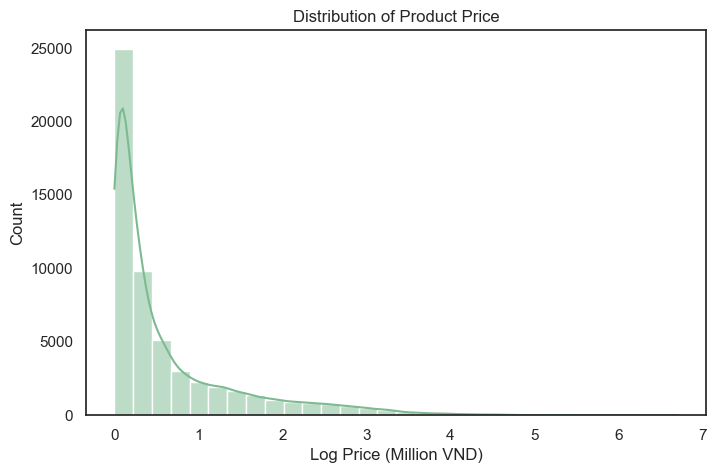

In [19]:
plt.figure(figsize=(8,5))
sns.histplot(np.log1p(df_product["price"] / 1e6), bins=30, kde=True)
plt.title("Distribution of Product Price")
plt.xlabel("Log Price (Million VND)")
plt.show()

Nhận xét: Biểu đồ cho thấy phân phối giá sản phẩm lệch phải mạnh (right-skewed) ngay cả khi đã dùng log. Phần lớn sản phẩm tập trung ở vùng giá thấp đến trung bình, trong khi chỉ một tỷ lệ nhỏ nằm ở mức giá rất cao, tạo thành “đuôi dài” về phía phải.

## Phân số số lượng bán

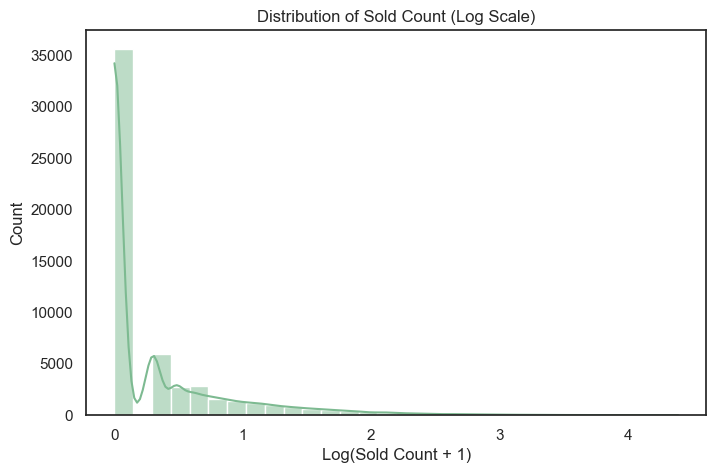

In [20]:
#lấy log để dễ nhìn hơn, vì giá có thể có nhiều outlier
plt.figure(figsize=(8,5))
sns.histplot(np.log10(df_product["sold_count"] + 1), bins=30, kde=True)
plt.title("Distribution of Sold Count (Log Scale)")
plt.xlabel("Log(Sold Count + 1)")
plt.show()

## Phân bố rating cửa hàng

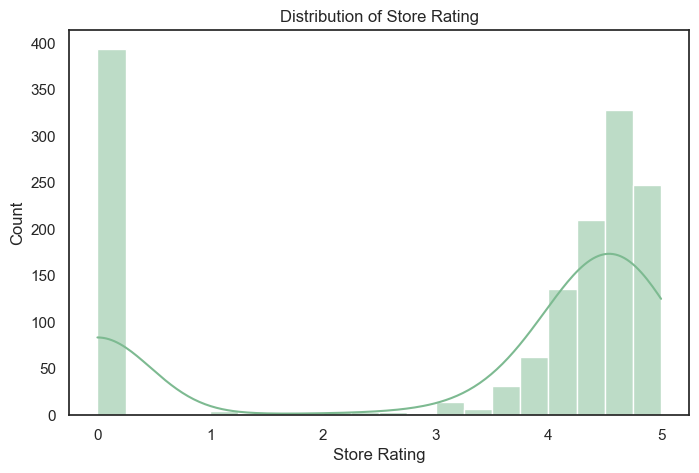

In [21]:
plt.figure(figsize=(8,5))
sns.histplot(df_store["store_rating"], bins=20, kde=True)
plt.title("Distribution of Store Rating")
plt.xlabel("Store Rating")
plt.show()

## Phân bố rating sản phẩm

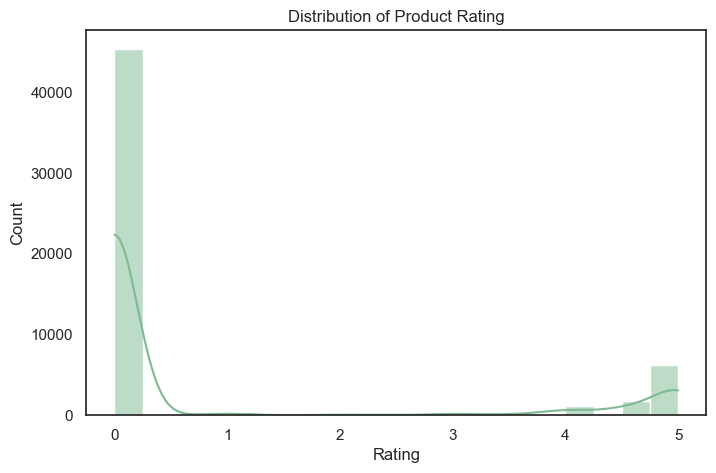

In [22]:
plt.figure(figsize=(8,5))
sns.histplot(df_product["rating_avg"], bins=20, kde=True)
plt.title("Distribution of Product Rating")
plt.xlabel("Rating")
plt.show()

# 6) Phân bố biến phân loại

### Biểu đồ tương tác cho toàn bộ cây category

Mục đích: Khám phá rõ hơn mối quan hệ giữa các category, đặc biệt là các category con và category cha, để từ đó có thể thiết kế biểu đồ tương tác phù hợp.

In [23]:
df_cat_product = df_product.merge(df_category, on="category_id", how="left")

cat_count = (
    df_cat_product.groupby(["parent_category", "category_name"])
    .size()
    .reset_index(name="product_count")
)

cat_count["parent_category"] = cat_count["parent_category"].fillna("Tiki Categories")

fig = px.treemap(
    cat_count,
    path=["parent_category", "category_name"],
    values="product_count",
    title="Category Treemap"
)

fig.show()


## Số lượng sản phẩm theo danh mục

In [24]:
sns.set_theme(style="whitegrid")
main_cmap = sns.color_palette("mako", as_cmap=True)

C:\Users\ADMIN\AppData\Local\Temp\ipykernel_84036\22838540.py:132: FutureWarning:



Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `y` variable to `hue` and set `legend=False` for the same effect.


C:\Users\ADMIN\AppData\Local\Temp\ipykernel_84036\22838540.py:132: UserWarning:

Numpy array is not a supported type for `palette`. Please convert your palette to a list. This will become an error in v0.14



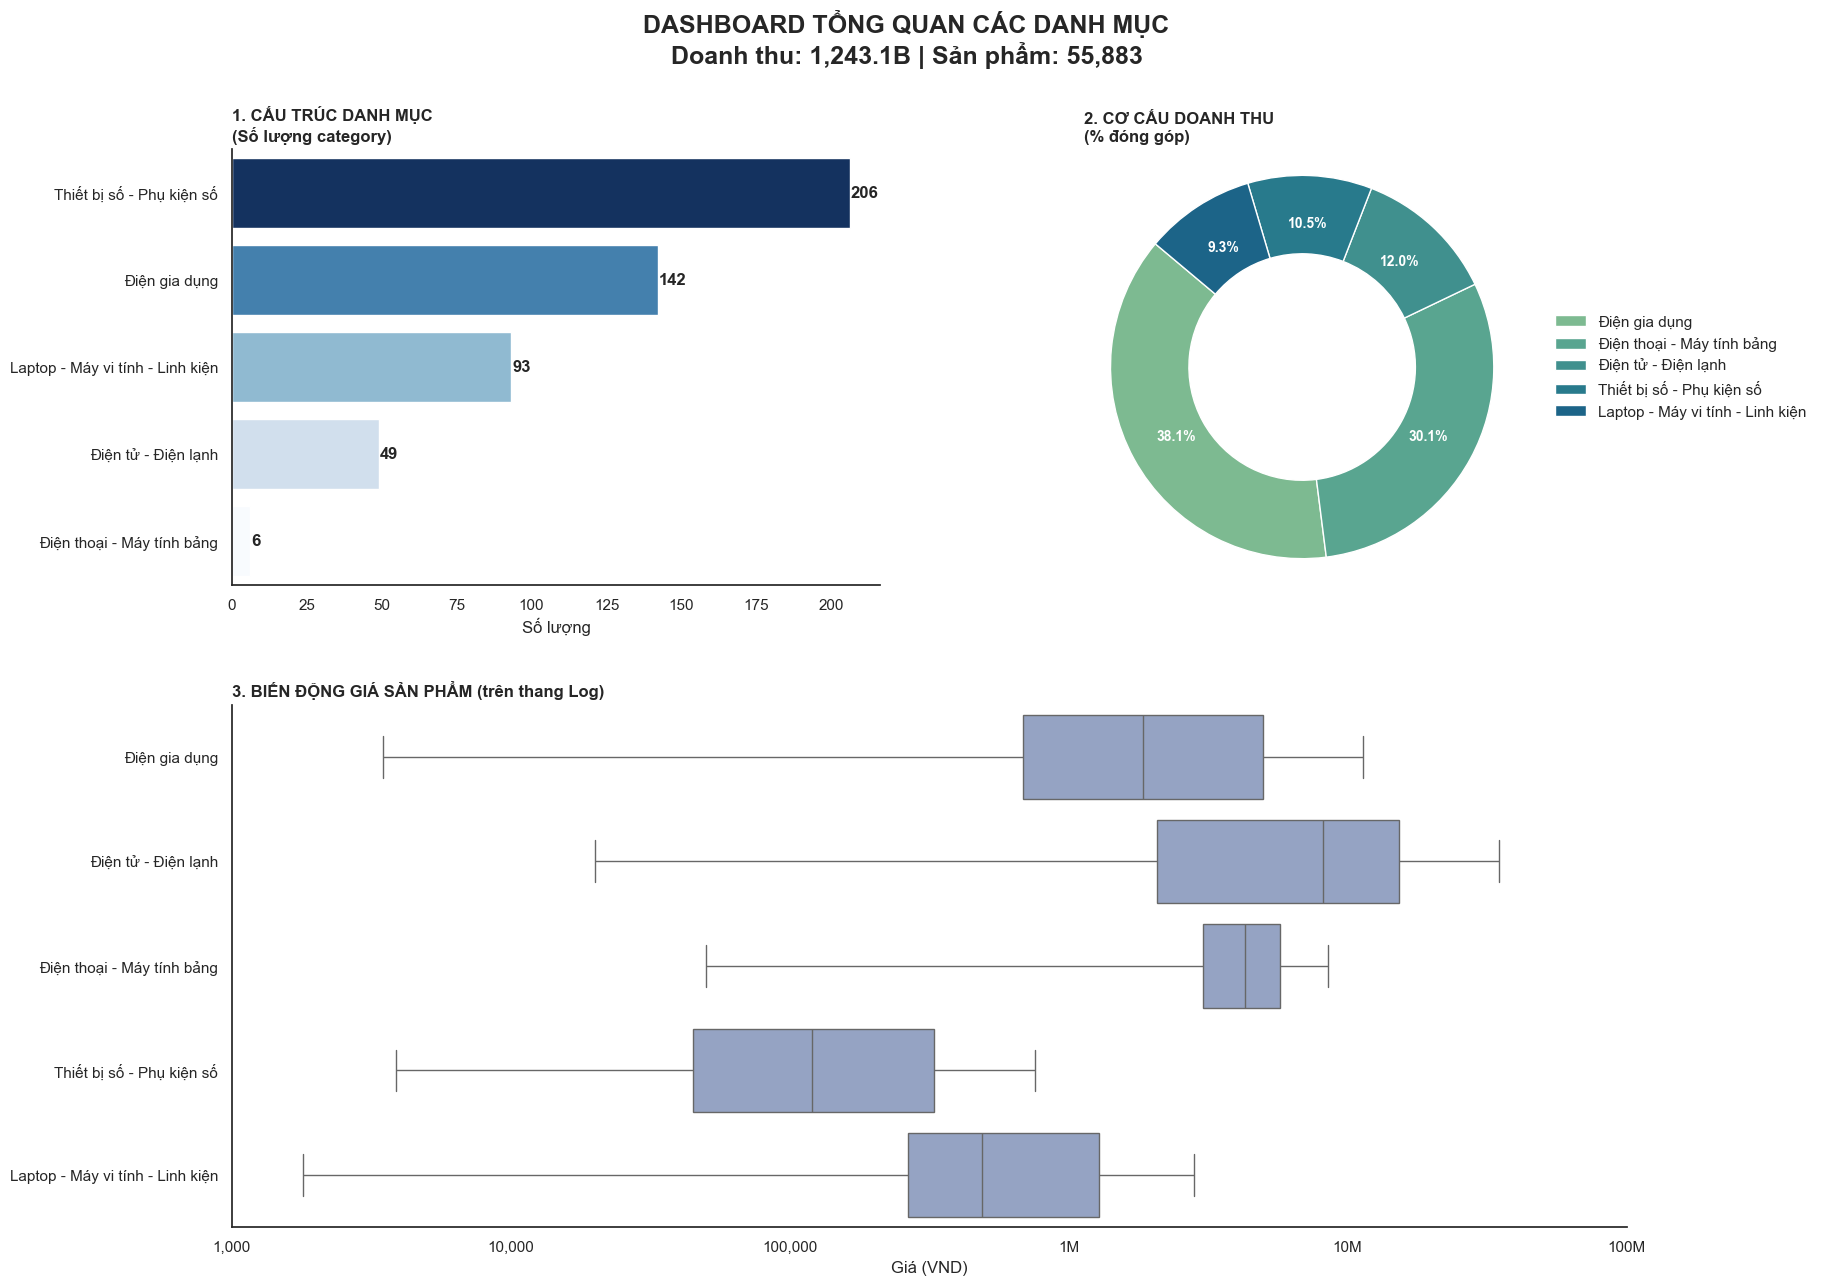

In [25]:
df_category_dashboard = df_category.copy()

df_category_dashboard["category_id"] = df_category_dashboard["category_id"].astype(str)
df_category_dashboard["parent_category"] = df_category_dashboard["parent_category"].astype("string")

name_to_id = dict(zip(
    df_category_dashboard["category_name"],
    df_category_dashboard["category_id"]
))

df_category_dashboard["parent_id"] = df_category_dashboard["parent_category"].map(name_to_id)

ROOT_IDS = set([
    "1882",  # Điện gia dụng
    "1789",  # Điện thoại - Máy tính bảng
    "4221",  # Điện tử - Điện lạnh
    "1846",  # Laptop - Máy vi tính - Linh kiện
    "1815",  # Thiết bị số - Phụ kiện số
])

parent_map = dict(zip(
    df_category_dashboard["category_id"],
    df_category_dashboard["parent_id"]
))

def find_root(cat_id):
    visited = set()
    
    while True:
        if cat_id in ROOT_IDS:
            return cat_id
        
        parent = parent_map.get(cat_id)
        
        if pd.isna(parent) or parent is None:
            return cat_id
        
        if parent in visited:
            return cat_id
        
        visited.add(cat_id)
        cat_id = parent

df_category_dashboard["root_category_id"] = df_category_dashboard["category_id"].apply(find_root)

id_to_name = dict(zip(
    df_category_dashboard["category_id"],
    df_category_dashboard["category_name"]
))

df_category_dashboard["root_category_name"] = df_category_dashboard["root_category_id"].map(id_to_name)

df_main = df_product.copy()
df_main["category_id"] = df_main["category_id"].astype(str)

cat_to_root = dict(zip(
    df_category_dashboard["category_id"],
    df_category_dashboard["root_category_name"]
))

df_main["root_category_name"] = df_main["category_id"].map(cat_to_root)

# ======================
# 2. BUILD DF_MAIN
# ======================
df_main = df_product.copy()
df_main["category_id"] = df_main["category_id"].astype(str)

# map category → root
cat_to_root = dict(zip(
    df_category_dashboard["category_id"],
    df_category_dashboard["root_category_name"]
))

df_main["root_category_name"] = df_main["category_id"].map(cat_to_root)

# ⚠️ fallback nếu map fail (rất quan trọng)
df_main["root_category_name"] = df_main["root_category_name"].fillna("Unknown")

# ======================
# 3. CLEAN NUMERIC
# ======================
df_main["price"] = pd.to_numeric(df_main["price"], errors="coerce").fillna(0)
df_main["sold_count"] = pd.to_numeric(df_main["sold_count"], errors="coerce").fillna(0)

# revenue
df_main["revenue"] = df_main["price"] * df_main["sold_count"]

# ======================
# 4. STYLE
# ======================
plt.rcParams['font.family'] = 'sans-serif'
sns.set_theme(style="white", palette="crest")

fig = plt.figure(figsize=(18, 14))
gs = fig.add_gridspec(2, 2, height_ratios=[1, 1.2], wspace=0.15, hspace=0.25)

def format_money(x, pos):
    if x >= 1_000_000_000: return f'{x / 1_000_000_000:,.1f}B'
    if x >= 1_000_000: return f'{x / 1_000_000:,.0f}M'
    return f'{x:,.0f}'

# ======================
# FILTER TOP 5 ROOT CATEGORY
# ======================
top5_roots = (
    df_main.groupby("root_category_name")["revenue"]
    .sum()
    .sort_values(ascending=False)
    .head(5)
    .index
)

df_main_top5 = df_main[df_main["root_category_name"].isin(top5_roots)]
df_category_top5 = df_category_dashboard[
    df_category_dashboard["root_category_name"].isin(top5_roots)
]

# bar
ax1 = fig.add_subplot(gs[0, 0])

sub_cat_count = (
    df_category_top5
    .groupby("root_category_name")["category_id"]
    .count()
    .sort_values(ascending=False)
)

norm = plt.Normalize(sub_cat_count.min(), sub_cat_count.max())
colors = cm.Blues(norm(sub_cat_count.values))

sns.barplot(
    x=sub_cat_count.values,
    y=sub_cat_count.index,
    palette=colors,
    ax=ax1
)

ax1.set_title('1. CẤU TRÚC DANH MỤC\n(Số lượng category)', loc='left', fontweight='bold')
ax1.set_xlabel('Số lượng')
ax1.set_ylabel('')

for i, v in enumerate(sub_cat_count.values):
    ax1.text(v + 0.5, i, f'{int(v)}', va='center', fontweight='bold')

sns.despine(ax=ax1)

# donut
ax2 = fig.add_subplot(gs[0, 1])

revenue_by_root = (
    df_main_top5.groupby("root_category_name")["revenue"]
    .sum()
    .sort_values(ascending=False)
)

wedges, texts, autotexts = ax2.pie(
    revenue_by_root.values,
    autopct='%1.1f%%',
    startangle=140,
    pctdistance=0.75,
    radius=1.1,
    wedgeprops={'width': 0.45, 'edgecolor': 'w'}
)

ax2.legend(
    wedges,
    revenue_by_root.index,
    loc="center left",
    bbox_to_anchor=(1.05, 0.5),
    frameon=False
)

plt.setp(autotexts, size=10, weight="bold", color="white")

ax2.set_title('2. CƠ CẤU DOANH THU\n(% đóng góp)', loc='left', fontweight='bold')

#boxplot
ax3 = fig.add_subplot(gs[1, :])

top_roots = (
    df_main["root_category_name"]
    .value_counts()
    .head(5)
    .index
)

df_box = df_main_top5[
    df_main_top5["price"] > 0
]

sns.boxplot(
    data=df_box,
    x="price",
    y="root_category_name",
    showfliers=False,
    color="#8da0cb", 
    ax=ax3
)

ax3.set_xscale("log")

ticks = [1e3, 1e4, 1e5, 1e6, 1e7, 1e8]
ax3.set_xticks(ticks)
ax3.xaxis.set_major_formatter(FuncFormatter(format_money))

ax3.set_title('3. BIẾN ĐỘNG GIÁ SẢN PHẨM (trên thang Log)', loc='left', fontweight='bold')
ax3.set_xlabel('Giá (VND)')
ax3.set_ylabel('')

sns.despine(ax=ax3)

# ======================
# TITLE
# ======================
total_rev = df_main["revenue"].sum()

fig.suptitle(
    f"DASHBOARD TỔNG QUAN CÁC DANH MỤC\n"
    f"Doanh thu: {format_money(total_rev, None)} | Sản phẩm: {len(df_main):,}",
    fontsize=18,
    fontweight='bold'
)

plt.show()

In [26]:
df_product_category = df_product.merge(
    df_category,
    on="category_id",
    how="left"
)

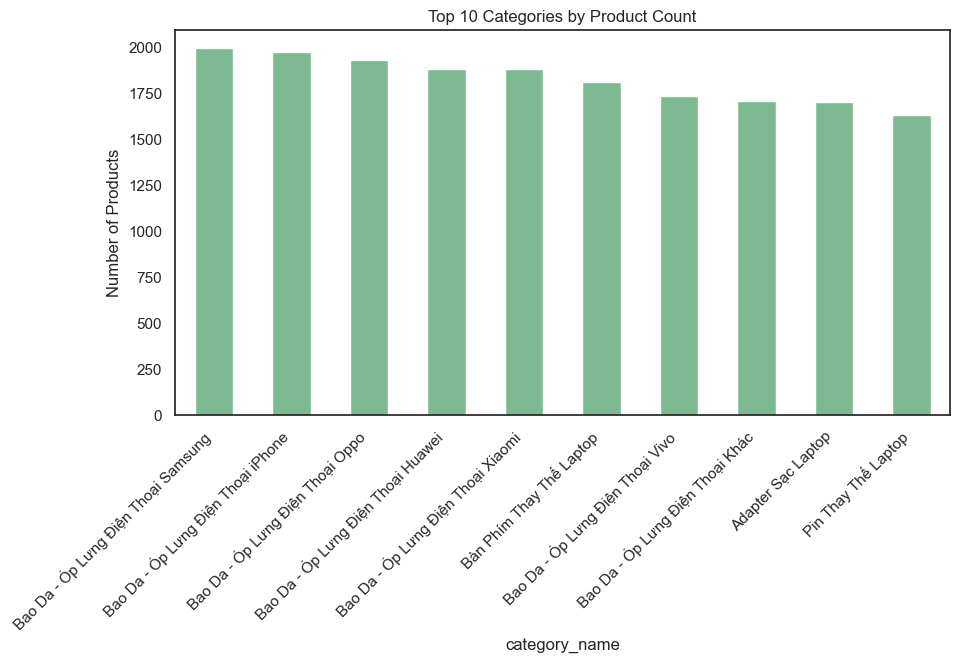

In [27]:
plt.figure(figsize=(10,5))
df_product_category["category_name"].value_counts().head(10).plot(kind="bar")
plt.title("Top 10 Categories by Product Count")
plt.ylabel("Number of Products")
plt.xticks(rotation=45, ha="right")
plt.show()